# DAT494 Final - DylFM (DylFusion Model)

### Setup

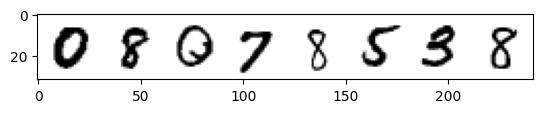

In [ ]:
# Imports for the model
import torch
import torchvision
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader


# Fetching the data
mnist = torchvision.datasets.MNIST(root="mnist/", train=True, download=True, transform=torchvision.transforms.ToTensor())

# Making sure everything is loaded
train_loader = DataLoader(mnist, batch_size=8, shuffle=True)
x, y = next(iter(train_loader))
plt.imshow(torchvision.utils.make_grid(x)[0], cmap='binary')

### Adding noise
The way a diffusion model works is by adding noise and having the model try to predict the noise.

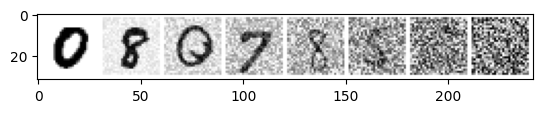

In [73]:
def noisify(input, noise_amount):
    """
    Noise: Creates a random number tensor with the same size as input
    Amount: -1 Infers size of dimension, 1,1,1 allows us to utilize broadcasting
    Noise Calculation is based off the tensor that gets passed in, for this example I am using a noise from 0 to 1 over the shape of x from the loader
    """
    noise = torch.rand_like(input)
    #input + noise_amount.view(-1, 1, 1, 1) * (noise + input)
    return torch.lerp(input, noise, noise_amount.view(-1, 1, 1, 1))

# Making sure it works
noise_range = torch.linspace(0,1,x.shape[0])

noise_test = noisify(x, noise_range)

plt.imshow(torchvision.utils.make_grid(noise_test)[0], cmap='binary')


### Basic Unet Architecture
#### Down Layers
1. ConvLayer 1 in, 32 out, 5 kernel, 1 stride, 2 padding -> GeLU -> Maxpool (Skip connection)
2. ConvLayer 32 in, 64 out, 5 kernel, 1 stride, 2 padding -> GeLU -> Maxpool (Skip Connection)
3. ConvLayer 64 in, 64 out, 5 kernel, 1 stride, 2 padding, GeLU
#### Up Layers
4. ConvLayer 64 in. 64 out, 5 kernel, 1 stide, 2 padding -> GeLU -> Upsample 
5. ConvLayer 64 in, 32 out, 5 kernel, 1 stride, 2 padding -> GeLU -> Upsample (Skip from Layer 2)
6. ConvLayer 32 in, 1 out, 5 kernel, 1 stride, 2 padding -> GeLU -> Upsample (Skip from layer 1)

In [66]:
# UNet
class Unet(nn.Module):
    def __init__(self):
        super().__init__()
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.gelu = nn.GELU()
        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")

        # "Down" Layers: 1-3
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=5, stride=1, padding=2)

        # "Up" Layers: 4-6
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.conv5 = nn.Conv2d(in_channels=96, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.conv6 = nn.Conv2d(in_channels=32, out_channels=1, kernel_size=5, stride=1, padding=2)

    def forward(self, x):
        skips = []

        #Down Layers
        x = self.gelu(self.conv1(x))
        skips.append(x) #skips[0]
        x = self.pool(x)

        x = self.gelu(self.conv2(x))
        skips.append(x) #skips[1]
        x = self.pool(x)

        x = self.gelu(self.conv3(x))

        #Up Layers
        x = self.upsample(x)
        x = torch.cat([x, skips[1]], dim=1)
        x = self.gelu(self.conv4(x))

        x = self.upsample(x)
        x = torch.cat([x, skips[0]], dim=1)
        x = self.gelu(self.conv5(x))

        x = self.conv6(x)
        return x

In [113]:
model = Unet()
x = torch.rand(8, 1, 28, 28)

assert model(x).shape == x.shape, "❌ Incorrect Shape"
print(f"Model Input: {x.shape}\nModel Output: {model(x).shape}\n✅ Shapes Match")

Model Input: torch.Size([8, 1, 28, 28])
Model Output: torch.Size([8, 1, 28, 28])
✅ Shapes Match


In [68]:
# Training for 1 epoch
train_loader = DataLoader(mnist, batch_size=64, shuffle=True)

epochs = 1

loss_fun = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

loss_list = []

for epoch in range(epochs):
    for x, y in train_loader:
        noise = torch.rand(x.shape[0], 1, 1, 1)
        noise_x = noisify(x, noise)

        pred = model(noise_x)

        loss = loss_fun(pred, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_list.append(loss.item())
    print(epoch+1)

    
plt.plot(loss_list)

KeyboardInterrupt: 

In [ ]:
#torch.save(model.state_dict(), "1_epoch.tr")

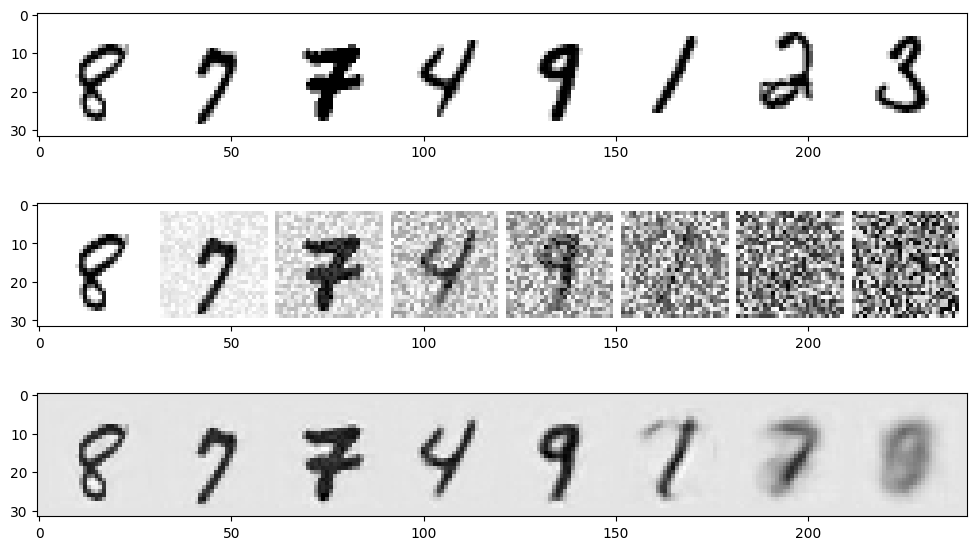

In [ ]:
#model.load_state_dict(torch.load("1_epoch.tr"))
#model.load_state_dict(torch.load("15_epoch.tr"))
X, y = next(iter(train_loader))
x = X[:8]

noise_amount = torch.linspace(0,1, x.shape[0])
x_noise = noisify(x, noise_amount)

with torch.no_grad():
    pred = model(x_noise.detach().cpu())

#print(pred.shape)


fig, axs = plt.subplots(3,1, figsize=(12,7))
axs[0].imshow(torchvision.utils.make_grid(x)[0], cmap='binary')
axs[1].imshow(torchvision.utils.make_grid(x_noise)[0], cmap='binary')
axs[2].imshow(torchvision.utils.make_grid(pred)[0], cmap='binary')

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10
Epoch: 11
Epoch: 12
Epoch: 13
Epoch: 14
Epoch: 15


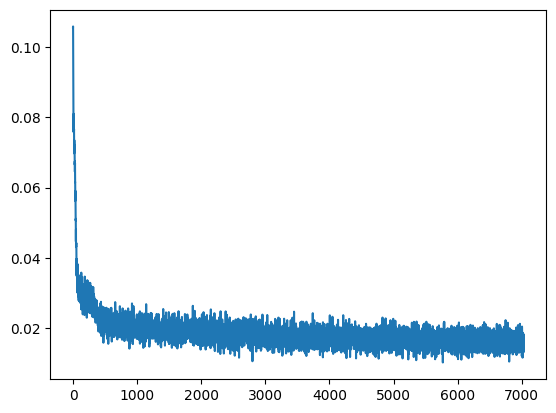

In [ ]:
#Training for more epochs
train_loader = DataLoader(mnist, batch_size=128, shuffle=True)
model_15 = Unet()

epochs = 15

loss_fun = nn.MSELoss()
optimizer = torch.optim.Adam(model_15.parameters(), lr=0.0001)

loss_list = []

for epoch in range(epochs):
    for x, y in train_loader:
        noise = torch.rand(x.shape[0], 1, 1, 1)
        noise_x = noisify(x, noise)

        pred = model_15(noise_x)

        loss = loss_fun(pred, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_list.append(loss.item())
    print(f"Epoch: {epoch+1}")

    
plt.plot(loss_list)

In [ ]:
#torch.save(model_15.state_dict(), "15_epoch.tr")

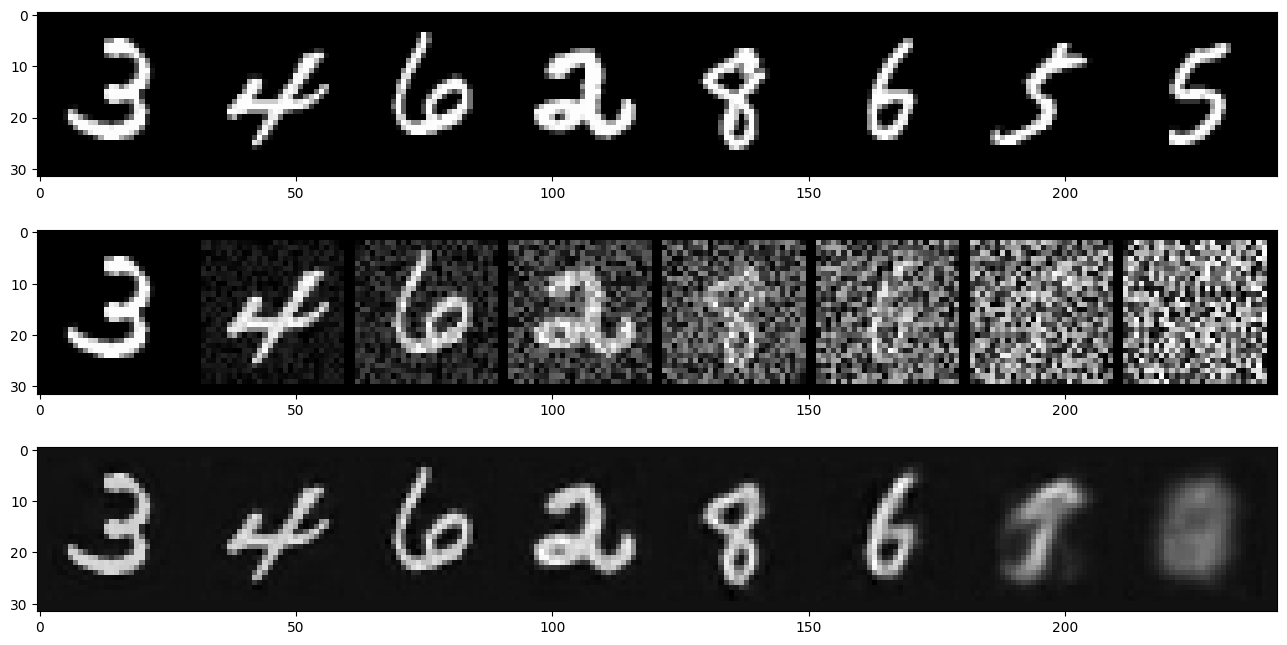

In [ ]:
#model.load_state_dict(torch.load("1_epoch.tr"))
#model.load_state_dict(torch.load("15_epoch.tr"))

X, y = next(iter(train_loader))

noise_amount = torch.linspace(0,1, X.shape[0])
x_noise = noisify(X, noise_amount)

with torch.no_grad():
    pred = model(x_noise.detach())

#print(pred.shape)

fig, axs = plt.subplots(3,1, figsize=(16,8))
axs[0].imshow(torchvision.utils.make_grid(X)[0], cmap='grey')
axs[1].imshow(torchvision.utils.make_grid(x_noise)[0], cmap='grey')
axs[2].imshow(torchvision.utils.make_grid(pred)[0], cmap='grey')

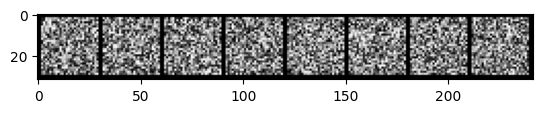

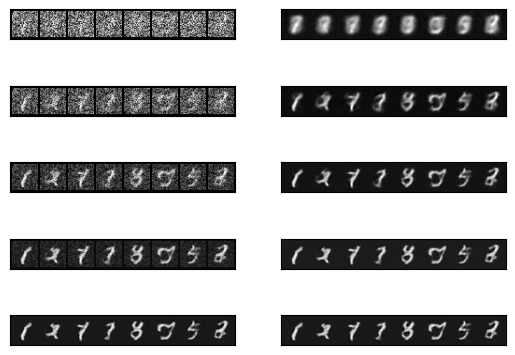

In [112]:
steps = 5
step_list = []
pred_list = []

x = torch.rand(8,1,28,28)
plt.imshow(torchvision.utils.make_grid(x)[0], cmap='grey')

for i in range(steps):
    with torch.no_grad():
        pred = model(x)
    pred_list.append(pred)
    mix = 1/(steps-i)
    x = x.lerp(pred, mix)
    step_list.append(x)

fig, axs = plt.subplots(steps, 2)
for i in range(steps):
    axs[i,0].imshow(torchvision.utils.make_grid(step_list[i])[0], cmap='grey')
    axs[i,0].set_xticks([])
    axs[i,0].set_yticks([])
    axs[i,1].imshow(torchvision.utils.make_grid(pred_list[i])[0], cmap='grey')
    axs[i,1].set_xticks([])
    axs[i,1].set_yticks([])